In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
import zipfile

with zipfile.ZipFile("archive (2).zip", "r") as zip_ref:
    zip_ref.extractall()

os.listdir()

['.ipynb_checkpoints',
 'archive (2).zip',
 'Netflix_EDA.ipynb',
 'netflix_titles.csv']

In [5]:
df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [8]:
df.shape

(8807, 12)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [10]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [11]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

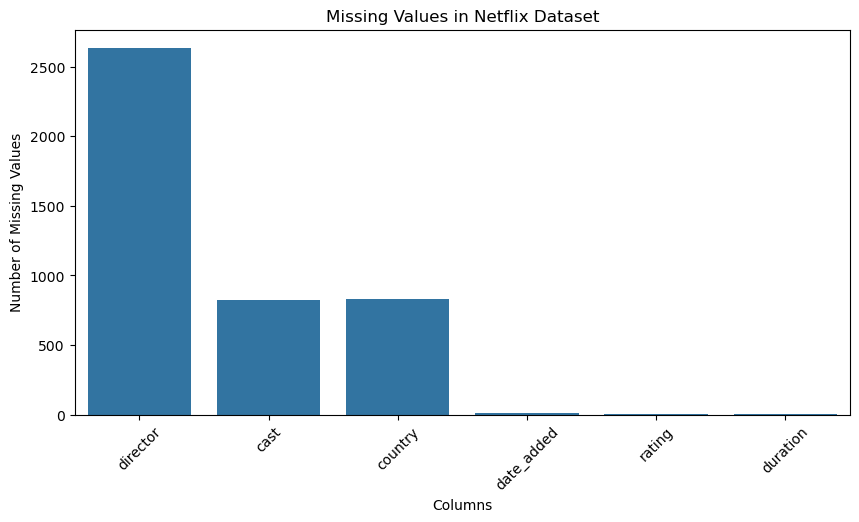

In [12]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

plt.figure(figsize=(10, 5))
sns.barplot(x=missing_values.index, y=missing_values.values)

plt.title("Missing Values in Netflix Dataset")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)

plt.show()

In [13]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [14]:
df["release_year"].median()

2017.0

In [15]:
df["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [16]:
df["rating"].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [17]:
df["country"].value_counts().head(10)

country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

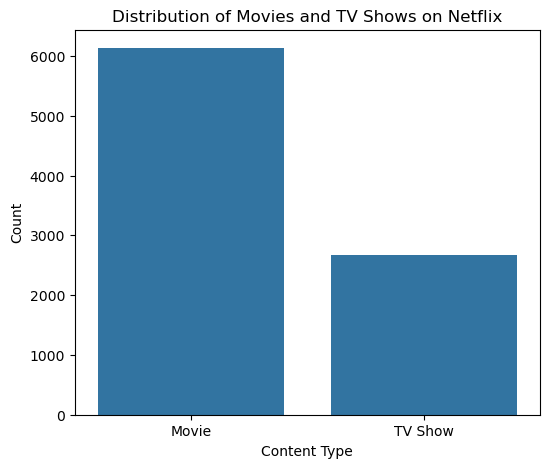

In [9]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x="type")

plt.title("Distribution of Movies and TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Count")

plt.show()

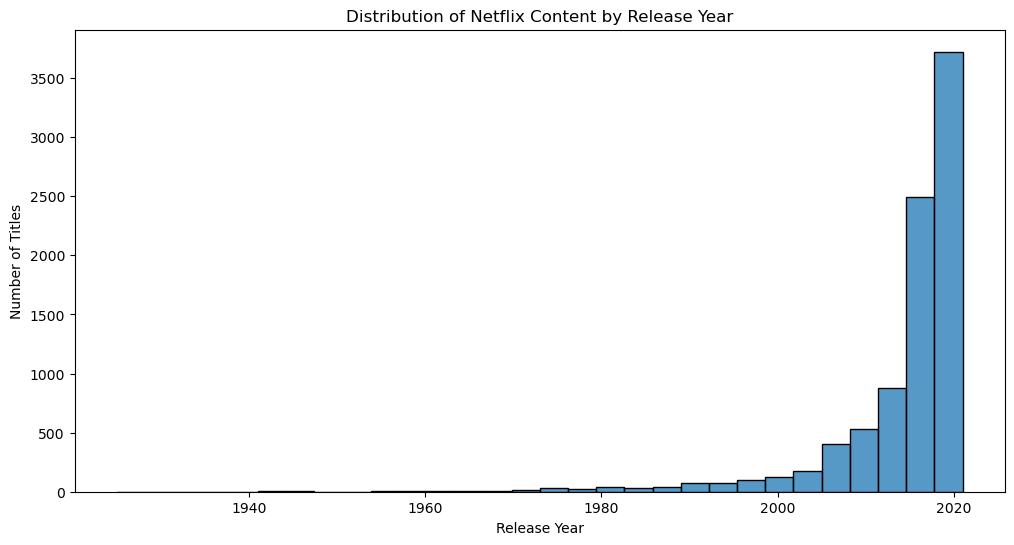

In [19]:
plt.figure(figsize=(12, 6))

sns.histplot(df["release_year"], bins=30)

plt.title("Distribution of Netflix Content by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

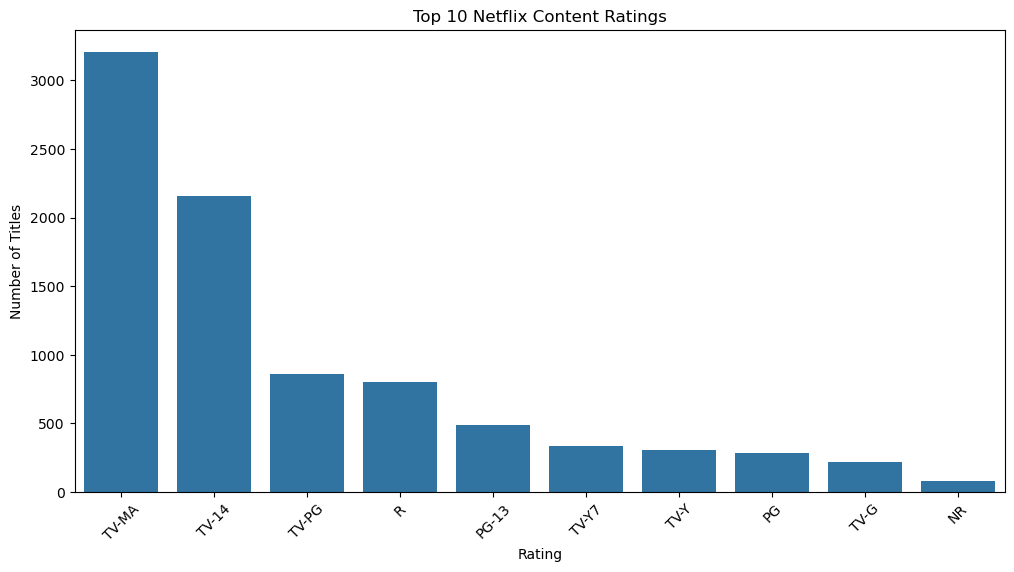

In [20]:
plt.figure(figsize=(12, 6))

rating_counts = df["rating"].value_counts().head(10)

sns.barplot(x=rating_counts.index, y=rating_counts.values)

plt.title("Top 10 Netflix Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()

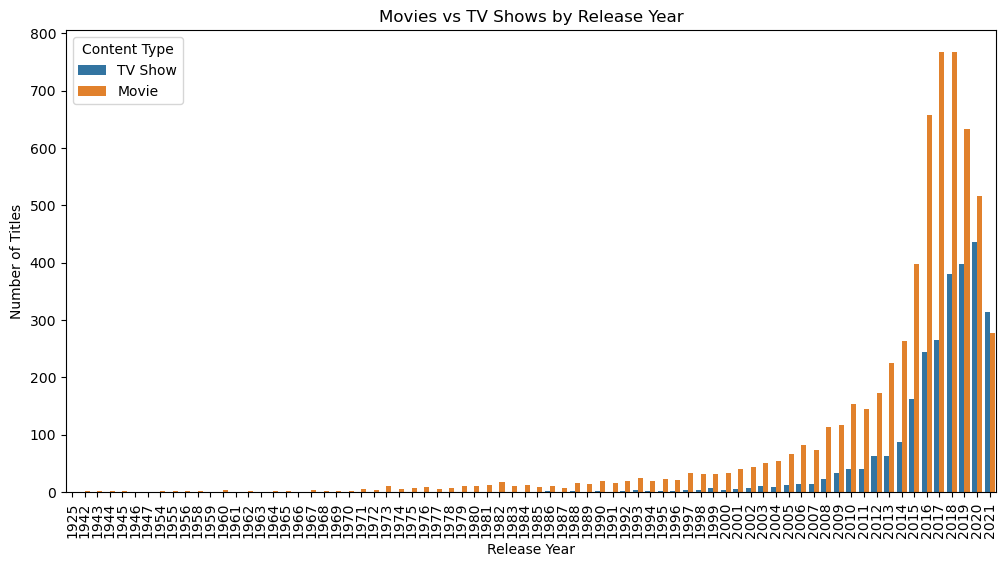

In [7]:
plt.figure(figsize=(12, 6))

sns.countplot(data=df, x="release_year", hue="type")

plt.title("Movies vs TV Shows by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.xticks(rotation=90)
plt.legend(title="Content Type")
plt.show()

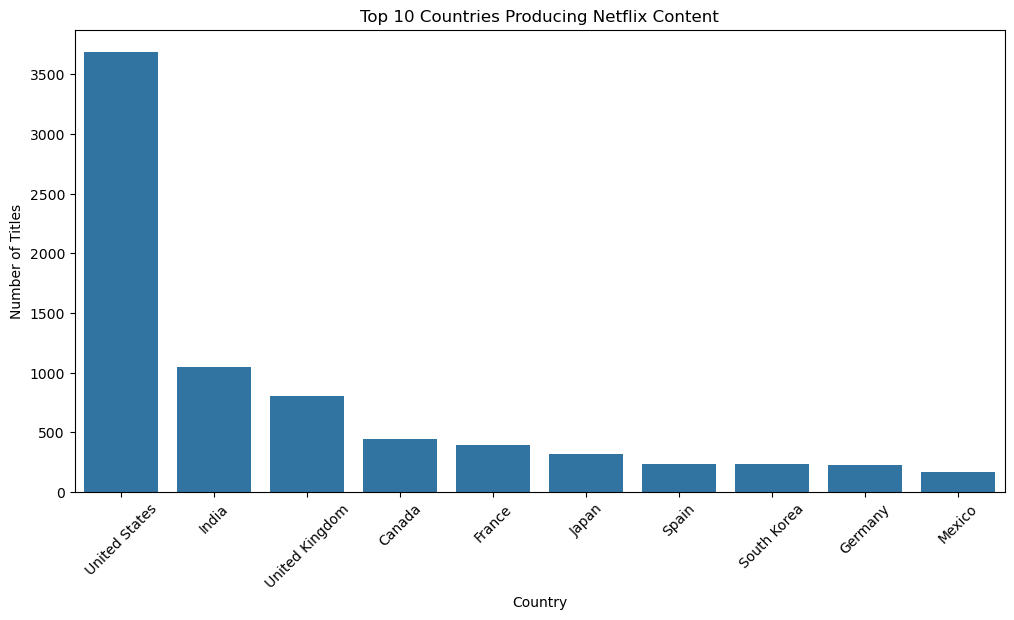

In [8]:
plt.figure(figsize=(12, 6))

country_counts = df["country"].dropna().str.split(", ").explode().value_counts().head(10)

sns.barplot(x=country_counts.index, y=country_counts.values)

plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)
plt.show()

## Visualization Insights

1. Movies are more numerous than TV Shows in the Netflix dataset. This indicates that movies make up a larger share of the Netflix content library.

2. Most Netflix content in the dataset was released in recent years. The number of titles increases significantly after 2000, showing a stronger presence of modern content.

3. TV-MA and TV-14 are among the most common content ratings. This indicates that a large portion of the content is targeted toward mature and teenage audiences.

4. Movies generally appear more frequently than TV Shows across most release years. This shows that movies have consistently formed a larger part of the Netflix catalog.

5. The United States is the leading content-producing country in the dataset, while India also has a significant presence. This shows the strong contribution of both countries to Netflix content.

## Dataset Source

Dataset: Netflix Movies and TV Shows

Source: Kaggle

The dataset contains information about Netflix movies and TV shows, including title, type, director, cast, country, release year, rating, duration, genres, and description.